<a href="https://colab.research.google.com/github/ghulammuhayyudin/Array-Display/blob/main/FYP_26_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bank Marketing Campaign: Predicting Term Deposit Subscriptions Using Direct Marketing Data**

# **Import and Load Dataset**

In [ ]:
pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# Data as pandas dataframes
X = bank_marketing.data.features
y = bank_marketing.data.targets

# Combine for easier inspection and EDA
df = pd.concat([X, y], axis=1)

# **Inspect the Dataset**
This step helps you understand the structure, data types, and identify missing values.

In [ ]:
# View first few rows
print(df.head())

# Check data types and non-null counts
print(df.info())

# Summary statistics for numerical columns
print(df.describe())

# Check for missing values
print(df.isnull().sum())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  
3     NaN            5   may        92         1     -1         0      NaN  no  
4     NaN            5   may       198         1     -1         0      NaN  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to

# **Preprocessing**
The Bank Marketing dataset often uses "unknown" as a placeholder for missing values. We also need to encode categorical variables for modeling.

In [ ]:
import pandas as pd
import numpy as np

# 1. Handle "unknown" values by converting to NaNs for standard processing
df.replace('unknown', np.nan, inplace=True)

# 2. Binary Encoding for the target variable 'y'
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# 3. Targeted Missing Value Imputation
# For columns with very high null counts (poutcome), it's safer to categorize them
df['poutcome'] = df['poutcome'].fillna('not_contacted')

# For others, we use the Mode (most frequent value)
cols_to_fix = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact']
for col in cols_to_fix:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# 4. Drop redundant or constant columns
# We drop 'was_contacted' because it has zero variance (constant value)
# We often drop 'duration' for predictive modeling because it's not known before a call
df.drop(columns=['was_contacted'], inplace=True, errors='ignore')

# 5. Final Verification
print("Missing values after preprocessing:")
print(df.isnull().sum())
print(f"\nRemaining columns: {df.columns.tolist()}")

Missing values after preprocessing:
age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day_of_week    0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
dtype: int64

Remaining columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


# **Exploratory Data Analysis (EDA)**
EDA helps reveal patterns between client attributes and their likelihood to subscribe to a term deposit.

## **A. Target Variable Distribution**

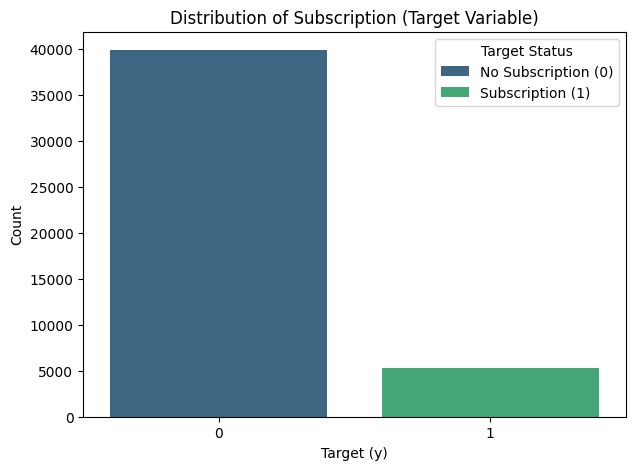

In [ ]:

# Create the figure
plt.figure(figsize=(7, 5))

# Plotting with 'hue' automatically creates a legend
# We map the legend labels to 'No Subscription' and 'Subscription'
ax = sns.countplot(x='y', data=df, hue='y', palette='viridis', legend=True)

# Customizing the legend to show meaningful labels
labels = ['No Subscription (0)', 'Subscription (1)']
h, l = ax.get_legend_handles_labels()
ax.legend(h, labels, title="Target Status")

# Adding titles and labels
plt.title('Distribution of Subscription (Target Variable)')
plt.xlabel('Target (y)')
plt.ylabel('Count')

plt.show()

## **B. Age vs. Subscription**

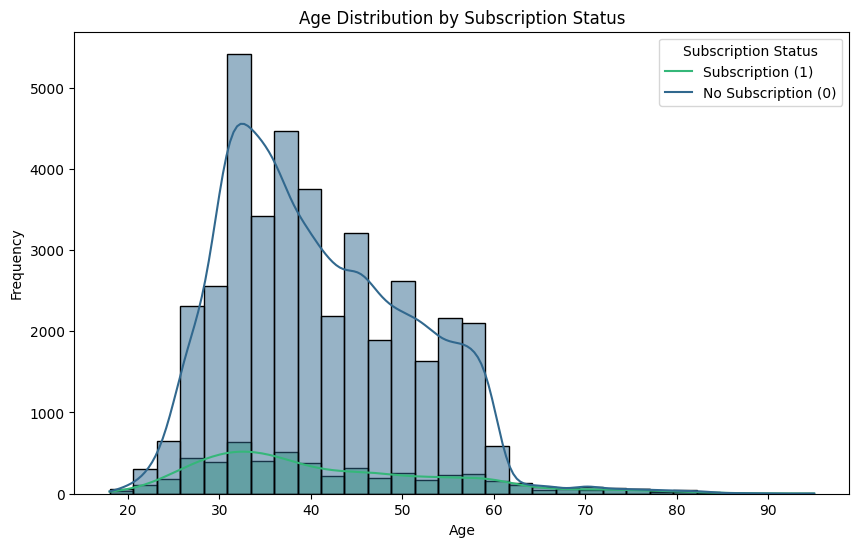

In [ ]:


plt.figure(figsize=(10,6))

# Create the histogram
ax = sns.histplot(data=df, x='age', hue='y', kde=True, bins=30, palette='viridis')

# Access the legend to change labels
# Note: In histplot, the legend is often created automatically if hue is used
plt.legend(title='Subscription Status', labels=['Subscription (1)', 'No Subscription (0)'])

plt.title('Age Distribution by Subscription Status')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

## **C. Job and Education Analysis**

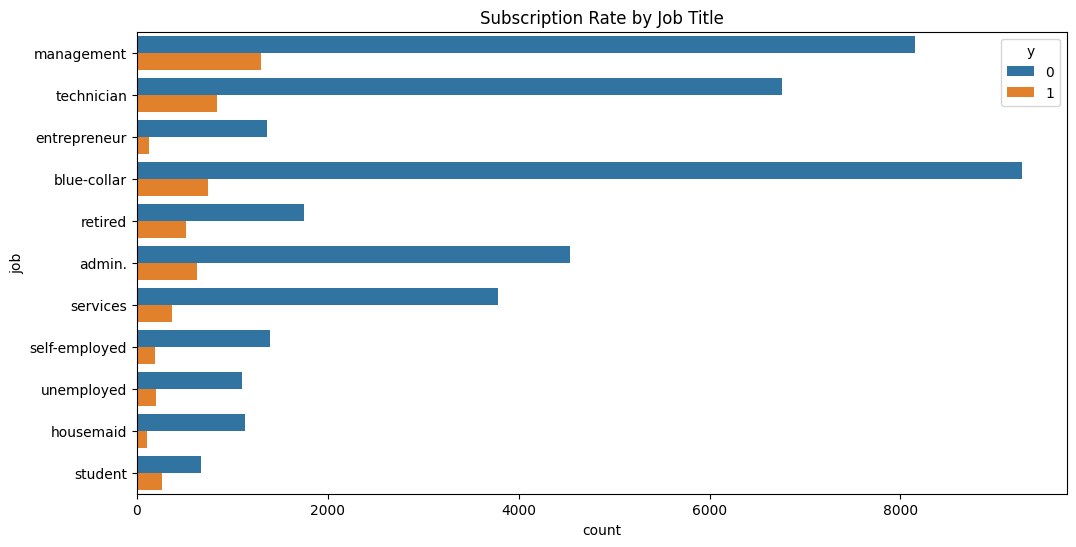

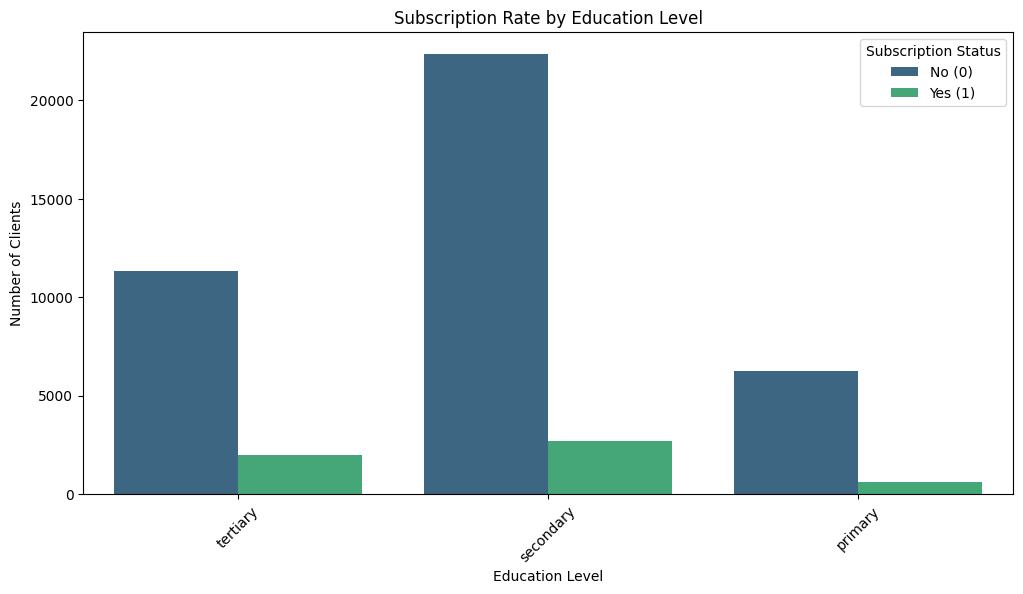

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(y='job', hue='y', data=df)
plt.title('Subscription Rate by Job Title')
plt.show()


plt.figure(figsize=(12,6))

# Create the countplot
ax = sns.countplot(x='education', hue='y', data=df, palette='viridis')

# Update legend labels
# Note: 0 is 'No' (No Subscription), 1 is 'Yes' (Subscribed)
plt.legend(title='Subscription Status', labels=['No (0)', 'Yes (1)'])

# Formatting
plt.xticks(rotation=45)
plt.title('Subscription Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Clients')

plt.show()

## **D. Correlation Heatmap**

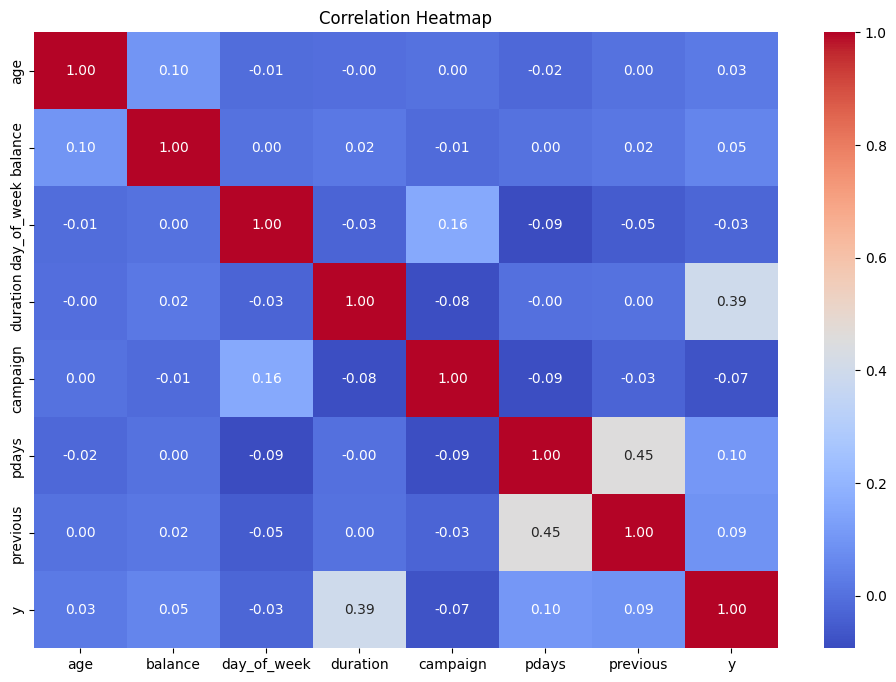

In [ ]:
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# **Data Preprocessing for Modeling**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Separate Features and Target
X = df.drop('y', axis=1)
y = df['y']

# 2. Identify column types
# Numerical columns need scaling; Categorical columns need encoding
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# 3. Create a Transformer for the pipeline
# This applies OneHotEncoding to cats and Scaling to nums simultaneously
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# 4. Apply the transformations
X_processed = preprocessor.fit_transform(X)

# 5. Get feature names (optional, for readability)
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

# Convert back to DataFrame for a clean view
X_final = pd.DataFrame(X_processed, columns=all_feature_names)

print("Preprocessed Data Head:")
print(X_final.head())

Preprocessed Data Head:
        age   balance  day_of_week  duration  campaign     pdays  previous  \
0  1.606965  0.256419    -1.298476  0.011016 -0.569351 -0.411453  -0.25194   
1  0.288529 -0.437895    -1.298476 -0.416127 -0.569351 -0.411453  -0.25194   
2 -0.747384 -0.446762    -1.298476 -0.707361 -0.569351 -0.411453  -0.25194   
3  0.571051  0.047205    -1.298476 -0.645231 -0.569351 -0.411453  -0.25194   
4 -0.747384 -0.447091    -1.298476 -0.233620 -0.569351 -0.411453  -0.25194   

   job_admin.  job_blue-collar  job_entrepreneur  ...  month_jun  month_mar  \
0         0.0              0.0               0.0  ...        0.0        0.0   
1         0.0              0.0               0.0  ...        0.0        0.0   
2         0.0              0.0               1.0  ...        0.0        0.0   
3         0.0              1.0               0.0  ...        0.0        0.0   
4         0.0              1.0               0.0  ...        0.0        0.0   

   month_may  month_nov  month_o

# **Model Training**

## **Model Initialization**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Split the processed data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

## **Model Training and Prediction**

In [ ]:
import time

results = {}

for name, model in models.items():
    # Training Time
    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()

    # Prediction/Testing Time
    start_test = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    end_test = time.time()

    # Store predictions and times for the next cell
    results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'train_time': end_train - start_train,
        'test_time': end_test - start_test
    }
    print(f"Finished training {name}")

Finished training Logistic Regression
Finished training SVM


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:37:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Finished training XGBoost


## **Initial Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

evaluation_metrics = []

for name, data in results.items():
    y_pred = data['y_pred']
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Train Time (s)": data['train_time'],
        "Test Time (s)": data['test_time']
    }
    evaluation_metrics.append(metrics)

# Display as a table
metrics_df = pd.DataFrame(evaluation_metrics)
print(metrics_df)

                 Model  Accuracy  Precision    Recall  F1-Score  \
0  Logistic Regression  0.898706   0.630515  0.324197  0.428215   
1                  SVM  0.903572   0.686000  0.324197  0.440308   
2              XGBoost  0.901692   0.610458  0.441399  0.512342   

   Train Time (s)  Test Time (s)  
0        0.587143       0.012534  
1      248.464059      11.104322  
2        0.670964       0.038578  


## **Model Visualizations**

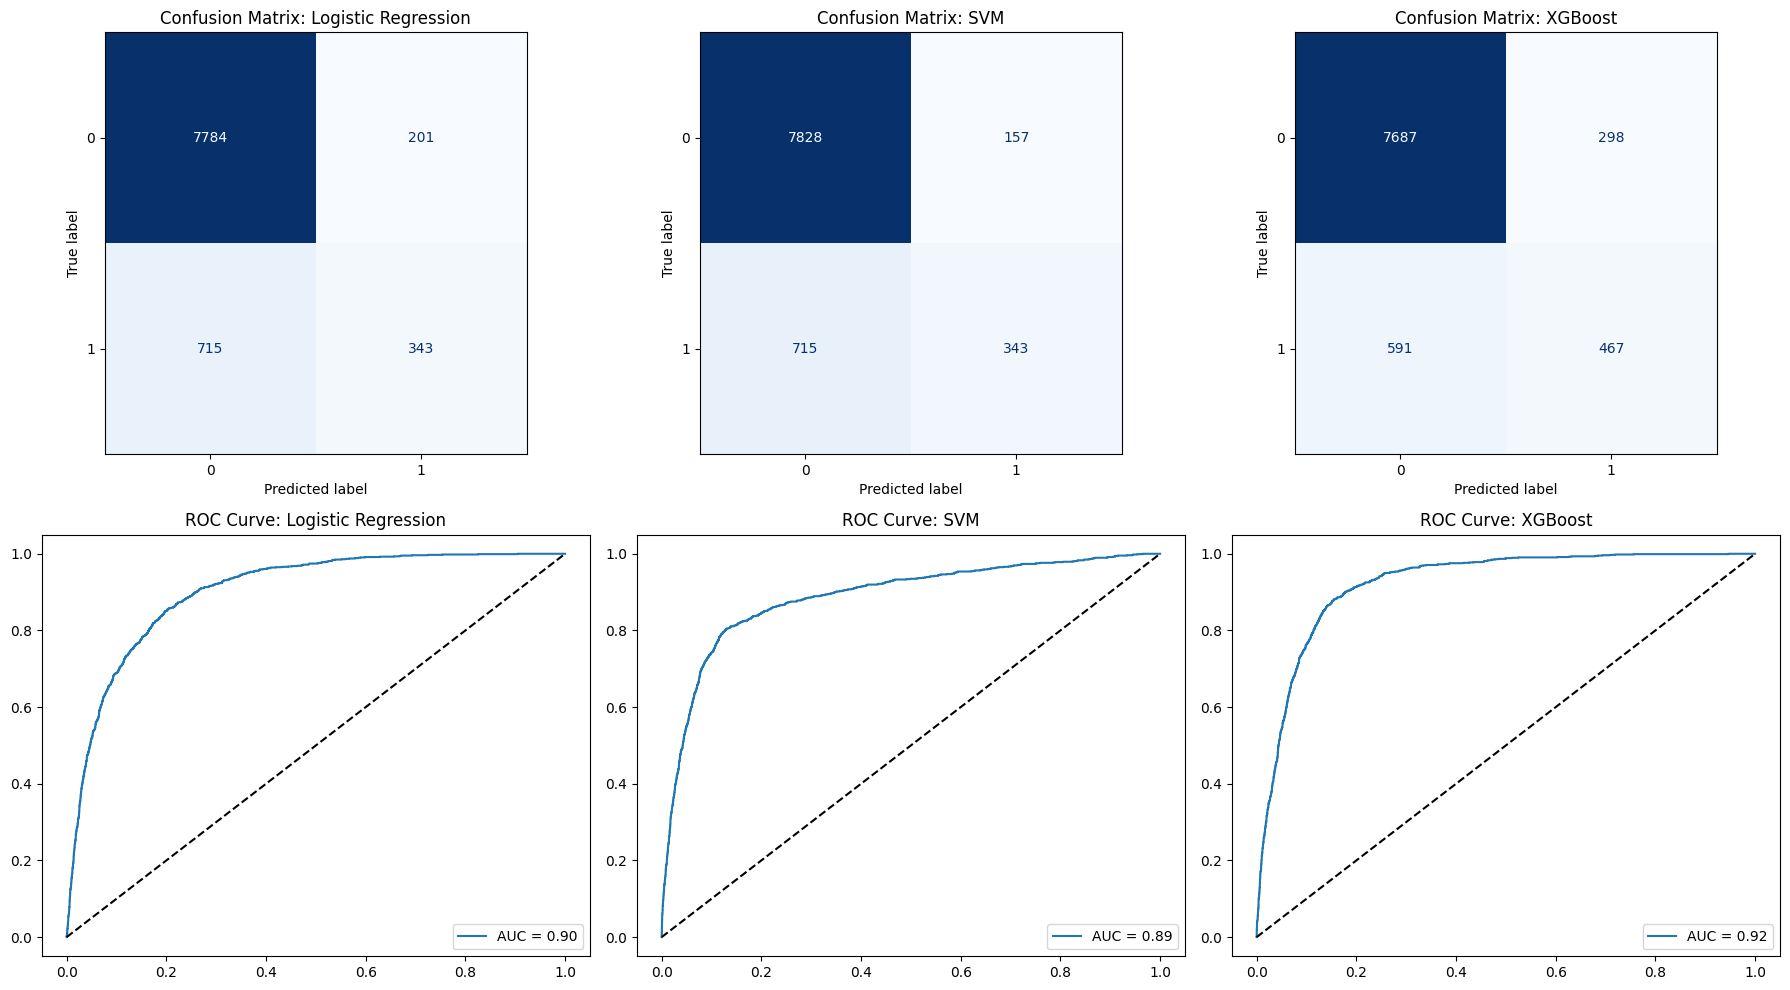

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, data) in enumerate(results.items()):
    # Confusion Matrix
    cm = confusion_matrix(y_test, data['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[0, i], cmap='Blues', colorbar=False)
    axes[0, i].set_title(f"Confusion Matrix: {name}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, data['y_prob'])
    roc_auc = auc(fpr, tpr)
    axes[1, i].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    axes[1, i].plot([0, 1], [0, 1], 'k--')
    axes[1, i].set_title(f"ROC Curve: {name}")
    axes[1, i].legend(loc='lower right')

plt.tight_layout()
plt.show()